# ENIGH 2018 - 2024: Cambios en el Bienestar Económico de los Hogares Mexicanos

## Introducción y Preparación de Datos

Primero vamos a importar Pandas y Numpy

In [99]:
!python -m pip install pandas numpy scipy

In [3]:
import pandas as pd
import numpy as np

Ahora vamos a asignar los Data Frames

In [4]:
enigh2018=pd.read_csv("concentradohogar2018.csv")

In [5]:
enigh2024=pd.read_csv("concentradohogar2024.csv")

Ahora revisaremos que shape tienen los dataframes

In [6]:
enigh2018.shape

(74647, 126)

In [7]:
enigh2024.shape

(91414, 126)

Utilizaremos pandas para que solo nos muestre un decimal en todos los data frames

In [8]:
pd.set_option('display.precision',1)

Ahora lo que haremos será quedarnos con las variables que nos interesan, en este caso tomaremos 20 de las 126 columnas para poder llevar acabo el proyecto

In [9]:
enigh2018=enigh2018[["folioviv","foliohog","factor","tot_integ","sexo_jefe","edad_jefe","educa_jefe","clase_hog","tam_loc","ing_cor","ingtrab","bene_gob","gasto_mon","alimentos","vesti_calz","vivienda","salud","transporte","educa_espa","comunica"]]

In [10]:
enigh2024=enigh2024[["folioviv","foliohog","factor","tot_integ","sexo_jefe","edad_jefe","educa_jefe","clase_hog","tam_loc","ing_cor","ingtrab","bene_gob","gasto_mon","alimentos","vesti_calz","vivienda","salud","transporte","educa_espa","comunica"]]

Verificamos que tengamos las 20 columnas y las filas que tenía antes

In [11]:
enigh2024.shape

(91414, 20)

In [12]:
enigh2018.shape

(74647, 20)

### Revisión superficial del ingreso corriente

Vamos a ver que nos dicen las tablas con sus estadísticos

In [13]:
enigh2018.describe()

,folioviv,foliohog,factor,tot_integ,sexo_jefe,edad_jefe,educa_jefe,clase_hog,tam_loc,ing_cor,ingtrab,bene_gob,gasto_mon,alimentos,vesti_calz,vivienda,salud,transporte,educa_espa,comunica
count,7.5e+04,74647.0,74647.0,74647.0,74647.0,74647.0,74647.0,74647.0,74647.0,7.5e+04,7.5e+04,74647.0,7.5e+04,74647.0,74647.0,74647.0,74647.0,74647.0,74647.0,74647.0
mean,1.6e+09,1.0,460.8,3.6,1.3,49.8,5.5,2.1,2.5,4.6e+04,3.1e+04,811.8,2.9e+04,10395.6,1314.0,2526.0,797.8,5918.1,3229.0,1227.0
std,9.3e+08,0.2,475.8,1.8,0.4,16.0,2.5,0.6,1.3,6.1e+04,3.7e+04,1567.2,2.8e+04,7563.3,2392.0,3656.7,4680.8,10526.9,7869.0,2020.8
min,1.0e+08,1.0,9.0,1.0,1.0,14.0,1.0,1.0,1.0,0.0e+00,0.0e+00,0.0,0.0e+00,0.0,0.0,0.0,0.0,0.0,0.0,0.0
25%,8.0e+08,1.0,167.0,2.0,1.0,38.0,4.0,2.0,1.0,2.0e+04,9.4e+03,0.0,1.3e+04,5451.3,0.0,725.0,0.0,1227.8,0.0,290.3
50%,1.6e+09,1.0,323.0,3.0,1.0,48.0,6.0,2.0,3.0,3.4e+04,2.2e+04,0.0,2.2e+04,8777.5,606.5,1636.5,23.5,3483.9,782.6,600.0
75%,2.4e+09,1.0,586.0,5.0,2.0,61.0,7.0,3.0,4.0,5.5e+04,4.1e+04,1394.0,3.5e+04,13352.0,1619.0,2956.5,450.0,7352.7,3270.0,1730.3
max,3.3e+09,5.0,6414.0,22.0,2.0,110.0,11.0,5.0,4.0,4.5e+06,1.8e+06,31868.8,1.5e+06,231415.5,166304.3,174000.0,455869.5,628555.5,337619.6,137700.0


In [14]:
enigh2024.describe()

,folioviv,foliohog,factor,tot_integ,sexo_jefe,edad_jefe,educa_jefe,clase_hog,tam_loc,ing_cor,ingtrab,bene_gob,gasto_mon,alimentos,vesti_calz,vivienda,salud,transporte,educa_espa,comunica
count,9.1e+04,91414.0,91414.0,91414.0,91414.0,91414.0,91414.0,91414.0,91414.0,9.1e+04,9.1e+04,91414.0,9.1e+04,91414.0,91414.0,91414.0,91414.0,9.1e+04,91414.0,91414.0
mean,1.6e+09,1.0,424.8,3.4,1.3,51.5,5.9,2.1,2.5,7.2e+04,4.7e+04,2598.1,4.3e+04,16356.8,1634.6,3704.7,1523.1,8.9e+03,3791.8,2063.7
std,9.3e+08,0.1,474.7,1.8,0.5,16.0,2.6,0.6,1.3,9.4e+04,5.2e+04,4871.0,3.9e+04,11752.8,2803.7,5608.8,6310.1,1.6e+04,9143.5,2653.3
min,1.0e+08,1.0,4.0,1.0,1.0,14.0,1.0,1.0,1.0,0.0e+00,0.0e+00,0.0,0.0e+00,0.0,0.0,0.0,0.0,0.0e+00,0.0,0.0
25%,8.0e+08,1.0,141.0,2.0,1.0,39.0,4.0,2.0,1.0,3.5e+04,1.5e+04,0.0,2.2e+04,8718.3,0.0,1053.0,0.0,2.4e+03,0.0,600.0
50%,1.6e+09,1.0,288.0,3.0,1.0,51.0,6.0,2.0,3.0,5.6e+04,3.6e+04,0.0,3.4e+04,13898.4,782.6,2211.3,190.8,5.7e+03,834.0,1650.0
75%,2.4e+09,1.0,526.0,4.0,2.0,63.0,8.0,2.0,4.0,8.9e+04,6.5e+04,3245.9,5.3e+04,20892.7,2054.3,4161.0,1041.6,1.1e+04,3808.8,2697.0
max,3.3e+09,4.0,7127.0,20.0,2.0,106.0,11.0,5.0,4.0,1.7e+07,2.3e+06,164367.4,1.6e+06,314459.9,110152.1,190500.0,493043.5,1.3e+06,336507.1,114710.3


Vamos a corregir la forma en la que se están viendo los datos

In [15]:
pd.set_option("display.float_format", "{:,.0f}".format)

Volvemos a correr el describe

In [16]:
enigh2024.describe()

,folioviv,foliohog,factor,tot_integ,sexo_jefe,edad_jefe,educa_jefe,clase_hog,tam_loc,ing_cor,ingtrab,bene_gob,gasto_mon,alimentos,vesti_calz,vivienda,salud,transporte,educa_espa,comunica
count,"91,414","91,414","91,414","91,414","91,414","91,414","91,414","91,414","91,414","91,414","91,414","91,414","91,414","91,414","91,414","91,414","91,414","91,414","91,414","91,414"
mean,"1,615,951,985",1,425,3,1,52,6,2,3,"72,274","47,446","2,598","43,411","16,357","1,635","3,705","1,523","8,863","3,792","2,064"
std,"932,140,550",0,475,2,0,16,3,1,1,"93,877","51,851","4,871","38,696","11,753","2,804","5,609","6,310","16,036","9,144","2,653"
min,"100,001,901",1,4,1,1,14,1,1,1,0,0,0,0,0,0,0,0,0,0,0
25%,"802,839,603",1,141,2,1,39,4,2,1,"34,521","14,583",0,"21,524","8,718",0,"1,053",0,"2,400",0,600
50%,"1,565,433,406",1,288,3,1,51,6,2,3,"55,666","36,411",0,"34,183","13,898",783,"2,211",191,"5,700",834,"1,650"
75%,"2,408,015,927",1,526,4,2,63,8,2,4,"88,841","65,010","3,246","53,047","20,893","2,054","4,161","1,042","10,633","3,809","2,697"
max,"3,260,593,818",4,"7,127",20,2,106,11,5,4,"17,431,978","2,347,826","164,367","1,635,931","314,460","110,152","190,500","493,043","1,315,006","336,507","114,710"


In [17]:
enigh2018.describe()

,folioviv,foliohog,factor,tot_integ,sexo_jefe,edad_jefe,educa_jefe,clase_hog,tam_loc,ing_cor,ingtrab,bene_gob,gasto_mon,alimentos,vesti_calz,vivienda,salud,transporte,educa_espa,comunica
count,"74,647","74,647","74,647","74,647","74,647","74,647","74,647","74,647","74,647","74,647","74,647","74,647","74,647","74,647","74,647","74,647","74,647","74,647","74,647","74,647"
mean,"1,615,772,854",1,461,4,1,50,6,2,3,"46,044","30,840",812,"28,990","10,396","1,314","2,526",798,"5,918","3,229","1,227"
std,"930,496,364",0,476,2,0,16,3,1,1,"61,234","37,072","1,567","28,436","7,563","2,392","3,657","4,681","10,527","7,869","2,021"
min,"100,013,601",1,9,1,1,14,1,1,1,0,0,0,0,0,0,0,0,0,0,0
25%,"804,680,906",1,167,2,1,38,4,2,1,"20,345","9,387",0,"13,436","5,451",0,725,0,"1,228",0,290
50%,"1,562,231,602",1,323,3,1,48,6,2,3,"33,573","22,293",0,"22,116","8,777",606,"1,636",23,"3,484",783,600
75%,"2,403,851,820",1,586,5,2,61,7,3,4,"55,196","40,940","1,394","35,428","13,352","1,619","2,956",450,"7,353","3,270","1,730"
max,"3,260,798,906",5,"6,414",22,2,110,11,5,4,"4,501,830","1,841,189","31,869","1,457,729","231,415","166,304","174,000","455,870","628,556","337,620","137,700"


### Ajuste por Inflación

Ya con los datos en orden podemos darnos cuenta que existe un incremento en el promedio del ingreso corriente que en 2018 era de 46,044 mxn y en 2024 era de 72,274. Pero recordemos que son pesos nominales, no están ajustados por la inflación. Debemos saber que entre 2018 - 2024 hubo aprox 34.8% de inflación, entonces tenemos un sesgo ahí que vamos a corregir.

Para el proyecto tomaremos como base 2018, entonces tendremos que dividir el ingreso corriente de 2024 entre el factor de inflación correspondiente. Para ello, utilizamos el promedio del INPC general (serie SF43718) de los meses en que se levantó cada ENIGH: agosto–noviembre de 2018 y agosto–noviembre de 2024 (INEGI, 2026).
El promedio del INPC en el periodo de levantamiento de 2018 fue de 101.288, y el de 2024 fue de 136.586. El factor de deflactación es de 1.348, lo que equivale a un incremento acumulado de precios de aproximadamente 34.8% entre ambos periodos de levantamiento.
Al dividir el ingreso corriente promedio de 2024 (72,274 mxn) entre dicho factor, obtenemos un ingreso en pesos constantes de 2018 de aproximadamente 53,615 mxn, lo que permite una comparación directa con los 46,044 mxn reportados en 2018. Esto implica un incremento real en el ingreso de alrededor del 16.4% entre ambos años.

Instituto Nacional de Estadística y Geografía. (2026). Índice Nacional de Precios al Consumidor (INPC general, serie SF43718). Sistema de Información Económica, Banco de México. Recuperado el 24 de abril de 2026, de https://www.banxico.org.mx/SieInternet/consultarDirectorioInternetAction.do?sector=8&accion=consultarCuadro&idCuadro=CP154&locale=es

In [18]:
enigh2024.iloc[:, 9:]= enigh2024.iloc[:, 9:]/1.348

In [19]:
enigh2024.describe()

,folioviv,foliohog,factor,tot_integ,sexo_jefe,edad_jefe,educa_jefe,clase_hog,tam_loc,ing_cor,ingtrab,bene_gob,gasto_mon,alimentos,vesti_calz,vivienda,salud,transporte,educa_espa,comunica
count,"91,414","91,414","91,414","91,414","91,414","91,414","91,414","91,414","91,414","91,414","91,414","91,414","91,414","91,414","91,414","91,414","91,414","91,414","91,414","91,414"
mean,"1,615,951,985",1,425,3,1,52,6,2,3,"53,615","35,197","1,927","32,204","12,134","1,213","2,748","1,130","6,575","2,813","1,531"
std,"932,140,550",0,475,2,0,16,3,1,1,"69,641","38,465","3,614","28,706","8,719","2,080","4,161","4,681","11,896","6,783","1,968"
min,"100,001,901",1,4,1,1,14,1,1,1,0,0,0,0,0,0,0,0,0,0,0
25%,"802,839,603",1,141,2,1,39,4,2,1,"25,609","10,818",0,"15,968","6,468",0,781,0,"1,780",0,445
50%,"1,565,433,406",1,288,3,1,51,6,2,3,"41,295","27,011",0,"25,358","10,310",581,"1,640",142,"4,228",619,"1,224"
75%,"2,408,015,927",1,526,4,2,63,8,2,4,"65,906","48,227","2,408","39,352","15,499","1,524","3,087",773,"7,888","2,826","2,001"
max,"3,260,593,818",4,"7,127",20,2,106,11,5,4,"12,931,734","1,741,711","121,934","1,213,599","233,279","81,715","141,320","365,759","975,524","249,634","85,097"


In [20]:
enigh2018.describe()

,folioviv,foliohog,factor,tot_integ,sexo_jefe,edad_jefe,educa_jefe,clase_hog,tam_loc,ing_cor,ingtrab,bene_gob,gasto_mon,alimentos,vesti_calz,vivienda,salud,transporte,educa_espa,comunica
count,"74,647","74,647","74,647","74,647","74,647","74,647","74,647","74,647","74,647","74,647","74,647","74,647","74,647","74,647","74,647","74,647","74,647","74,647","74,647","74,647"
mean,"1,615,772,854",1,461,4,1,50,6,2,3,"46,044","30,840",812,"28,990","10,396","1,314","2,526",798,"5,918","3,229","1,227"
std,"930,496,364",0,476,2,0,16,3,1,1,"61,234","37,072","1,567","28,436","7,563","2,392","3,657","4,681","10,527","7,869","2,021"
min,"100,013,601",1,9,1,1,14,1,1,1,0,0,0,0,0,0,0,0,0,0,0
25%,"804,680,906",1,167,2,1,38,4,2,1,"20,345","9,387",0,"13,436","5,451",0,725,0,"1,228",0,290
50%,"1,562,231,602",1,323,3,1,48,6,2,3,"33,573","22,293",0,"22,116","8,777",606,"1,636",23,"3,484",783,600
75%,"2,403,851,820",1,586,5,2,61,7,3,4,"55,196","40,940","1,394","35,428","13,352","1,619","2,956",450,"7,353","3,270","1,730"
max,"3,260,798,906",5,"6,414",22,2,110,11,5,4,"4,501,830","1,841,189","31,869","1,457,729","231,415","166,304","174,000","455,870","628,556","337,620","137,700"


En general observamos un incremento en el ingreso promedio en los hogares mexicanos, en términos nominales estamos hablando de un incremento del 65%, pero debemos de tomar en cuenta dos factores más, 1.- Serían los valores atípicos que nos muestran los datos, ya que tenemos ingresos corrientes de $0 mxn y de $4,501,830 mxn y 2.- Que el crecimiento fue nominal, no real.
Entonces para atacar el primer punto no tomaremos en cuenta el promedio, ya que los valores sesgan nuestros resultados, la mejor solución sería tomar la mediana ya que estadísticamente esta no se ve afectada por esos valores atípicos. Ahora bien tomando en cuenta la mediana podemos notar un crecimiento real del 23% ya descontando el 34.8% de inflación así de esta forma resolvemos los dos problemas anteriores. 
Es por esto que podemos decir que el crecimiento económico sí aumento un 23% por encima de la inflación, pero la siguiente pregunta es, ¿Ese crecimiento fue suficiente y benefició a todos por igual?
Eso lo resolveremos cuando veamos la distribución por deciles.

Vamos a ver los ingresos de la media con una gráfica

In [21]:
!python -m pip install matplotlib seaborn

In [22]:
import matplotlib as plt
import seaborn as sns

Aquí agregaré el año a cada DF para poder graficarlos de forma más sencilla

In [23]:
enigh2018['año']=2018
enigh2024['año']=2024

Ahora agregare los dos data frames en uno solo con la función de concatenar. En este caso usamos concat en vez de merge ya que necesitamos que las tablas estén una debajo de la otra porque recordemos que un data frame tiene más filas que otro y si los ponemos de lado con merge se rompe toda lógica

In [24]:
enigh=pd.concat([enigh2018,enigh2024], ignore_index=True)

Verificamos que tengamos buen orden en filas y columnas

In [25]:
enigh.head(20)

,folioviv,foliohog,factor,tot_integ,sexo_jefe,edad_jefe,educa_jefe,clase_hog,tam_loc,ing_cor,...,bene_gob,gasto_mon,alimentos,vesti_calz,vivienda,salud,transporte,educa_espa,comunica,año
0,100013601,1,179,3,1,74,4,2,1,"76,404",...,"1,623","18,551","5,618",0,"3,912",0,"8,400",0,"1,200",2018
1,100013602,1,179,5,1,48,11,2,1,"42,988",...,0,"55,471","20,930",401,"2,495","1,349","7,629","17,567","3,450",2018
2,100013603,1,179,2,1,39,10,2,1,"580,698",...,0,"103,107","37,594","2,015","4,475","28,859","12,326",0,"3,570",2018
3,100013604,1,179,2,2,70,8,2,1,"46,253",...,0,"19,340","2,893",98,"1,458",323,"7,350",639,"1,350",2018
4,100013606,1,179,4,2,51,4,2,1,"53,837",...,0,"13,605","7,367",0,300,57,600,0,600,2018
5,100026701,1,193,4,2,41,11,2,1,"237,743",...,0,"33,628",0,0,"2,801",0,"18,236","1,800","3,750",2018
6,100026703,1,193,1,2,57,9,1,1,"32,607",...,0,"33,311","11,456",0,"4,405","4,696","5,803",627,960,2018
7,100026704,1,193,2,1,53,11,2,1,"169,918",...,0,"87,119","30,986","1,565","1,050",0,"13,800","3,600","1,800",2018
8,100026706,1,193,3,1,30,6,2,1,"17,311",...,0,"14,347","5,773",533,"4,740",49,"1,356",0,"1,356",2018
9,100027201,1,190,4,1,69,4,3,1,"120,488",...,0,"52,373","3,986","1,174","16,199","8,217","13,859","1,776","1,921",2018


In [26]:
enigh.tail(20)

,folioviv,foliohog,factor,tot_integ,sexo_jefe,edad_jefe,educa_jefe,clase_hog,tam_loc,ing_cor,...,bene_gob,gasto_mon,alimentos,vesti_calz,vivienda,salud,transporte,educa_espa,comunica,año
166041,3260593022,1,183,4,1,35,6,2,4,"20,333",...,0,"21,208","10,825",617,820,"1,923","2,064","1,249",879,2024
166042,3260593023,1,183,2,1,61,3,2,4,"21,294",...,0,"12,772","4,597",0,584,"4,042","1,788","1,052",65,2024
166043,3260593024,1,183,6,1,42,6,2,4,"36,769",...,"1,089","25,438","6,676",755,918,0,"1,418","1,544","1,202",2024
166044,3260593301,1,183,3,1,41,6,2,4,"63,427",...,0,"37,981","19,438",435,"1,403","2,177","6,348",0,"2,041",2024
166045,3260593302,1,183,6,1,34,6,2,4,"125,002",...,0,"31,918","5,723","2,576",167,"2,177","6,702","6,238","2,394",2024
166046,3260593303,1,183,2,2,45,10,2,4,"38,048",...,0,"104,724","7,039",232,662,"87,058","5,409",162,"1,102",2024
166047,3260593304,1,183,4,1,44,8,2,4,"59,714",...,0,"43,640","14,536","5,864","2,090","2,685","7,575","5,705","2,841",2024
166048,3260593305,1,183,3,1,62,3,2,4,"20,260",...,0,"17,090","12,981",0,645,20,"2,726",0,0,2024
166049,3260593306,1,183,3,2,44,9,3,4,"45,966",...,0,"19,678","6,352","1,491",979,0,"5,926","1,134","5,302",2024
166050,3260593507,1,183,4,1,34,6,2,4,"21,784",...,0,"19,584","9,404","1,161",568,0,"2,925","2,906",987,2024


Si sumamos las filas del ENIGH2018 (74,647) + ENIGH2024 (91,414) vemos que el resultado es de 166,061. Entonces hay que comprobarlo

In [27]:
enigh.shape

(166061, 21)

In [28]:
enigh.columns

Index(['folioviv', 'foliohog', 'factor', 'tot_integ', 'sexo_jefe', 'edad_jefe',
       'educa_jefe', 'clase_hog', 'tam_loc', 'ing_cor', 'ingtrab', 'bene_gob',
       'gasto_mon', 'alimentos', 'vesti_calz', 'vivienda', 'salud',
       'transporte', 'educa_espa', 'comunica', 'año'],
      dtype='object')

Podemos observar que no hay ningún error de que existan columnas de más y que la tabla del ENIGH2024 quedo justo debajo de la del 2018, por lo tanto no tendremos problema en la discrepancia de los datos.

Antes de graficar veremos como estan acomodados los datos, orientado a la parte de ingresos del jefe del hogar dependiendo el nivel académico que tenga

In [29]:
educa_ing = enigh.groupby(['año', 'educa_jefe'])['ing_cor'].median()
print(educa_ing)

año   educa_jefe
2018  1             18,948
      2             20,057
      3             24,067
      4             29,401
      5             30,766
      6             33,847
      7             37,691
      8             42,148
      9             50,577
      10            67,974
      11           101,686
2024  1             25,282
      2             26,749
      3             28,822
      4             34,899
      5             36,204
      6             40,622
      7             44,180
      8             47,591
      9             57,033
      10            71,141
      11            99,839
Name: ing_cor, dtype: float64


Esta tabla es interesante ya que podemos observar que en todos los niveles educativos se registraron incrementos en el ingreso real entre 2018 y 2024, mientras que los hogares con un posgrado mostraron una reducción. Esto nos dice que hubo una compresión en la brecha de ingresos por nivel educativo durante el período que estamos revisando.

Ahora vamos a graficar, vamos a reiniciar el índice como precaución para evitar cualquier error y asegurarnos que seaborn puede leer los datos de forma correcta

In [30]:
educa_ing=educa_ing.reset_index()

In [31]:
import matplotlib.pyplot as plt

#Aquí volví a importar matplotlib con pyplot porque no me dejaba agregar los titulos.

Text(0.5, -0.02, 'Nota: Los ingresos están deflactados a pesos de 2018 (INPC, Banxico SF43718)')

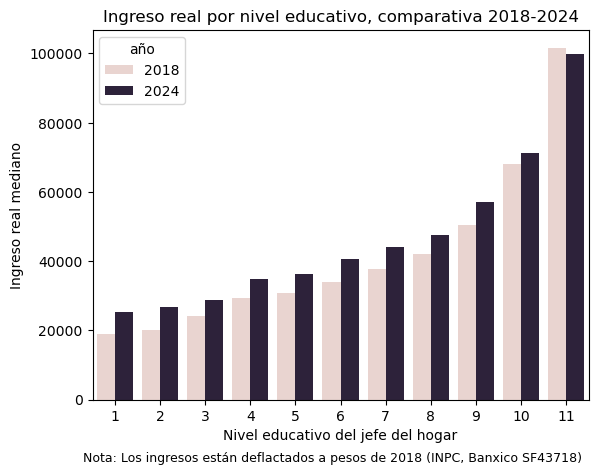

In [32]:
sns.barplot(data=educa_ing, x='educa_jefe', y='ing_cor', hue='año')
plt.xlabel("Nivel educativo del jefe del hogar")
plt.ylabel("Ingreso real mediano")
plt.title("Ingreso real por nivel educativo, comparativa 2018-2024")
plt.figtext(0.5, -0.02, 'Nota: Los ingresos están deflactados a pesos de 2018 (INPC, Banxico SF43718)', ha="center", fontsize=9)

Estos son los indicadores que nos da INEGI para los años de escolaridad
1 = Sin instrucción
2 = Preescolar
3 = Primaria incompleta
4 = Primaria completa
5 = Secundaria incompleta
6 = Secundaria completa
7 = Preparatoria incompleta
8 = Preparatoria completa
9 = Profesional incompleta
10 = Profesional completa
11 = Posgrado

## Perfil del Hogar

Vamos a ver cuántos hogares eran dirigidos por hombres (1) y cuántos por mujeres (2)

In [33]:
pd.pivot_table(enigh2018, values="folioviv", index="sexo_jefe", aggfunc="count")

,folioviv
sexo_jefe,
1,54171
2,20476


In [34]:
pd.pivot_table(enigh2024, values="folioviv",index="sexo_jefe",aggfunc="count")

,folioviv
sexo_jefe,
1,61852
2,29562


Como sabemos, tenemos diferentes cantidades de encuestas realizadas en los dos periodos, para tener un número confiable, vamos a dividir cada valor entre el total, para tener un porcentaje más acertado de acuerdo al periodo que estemos revisando.

In [35]:
len(enigh2018[enigh2018['sexo_jefe']==2])/len(enigh2018)*100

27.430439267485635

In [36]:
len(enigh2018[enigh2018['sexo_jefe']==1])/len(enigh2018)*100

72.56956073251438

Podemos observar que en el 2018 el porcentaje de hombres que eran jefe de familia representó un 72.57% y el porcentaje de mujeres siendo jefa de familia fue de 27.43% 

In [37]:
len(enigh2024[enigh2024['sexo_jefe']==2])/len(enigh2024)*100

32.33859146301442

In [38]:
len(enigh2024[enigh2024['sexo_jefe']==1])/len(enigh2024)*100

67.66140853698558

Ahora vemos que el porcentaje de jefe de familia hombre se redujo de un 72.57% a un 67.67% y el porcentaje de jefe de familia mujer aumentó de un 27.43% a un 32.34%

Vamos a ver estos datos en una gráfica

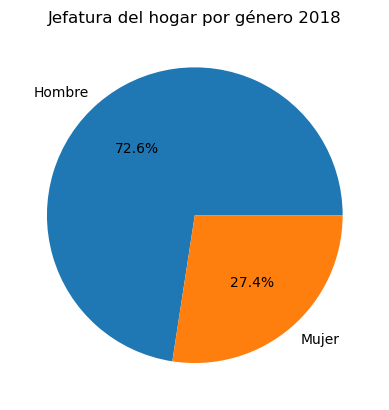

In [39]:
plt.pie([72.57,27.43], labels=['Hombre','Mujer'], autopct='%1.1f%%')
plt.title('Jefatura del hogar por género 2018')
plt.show()

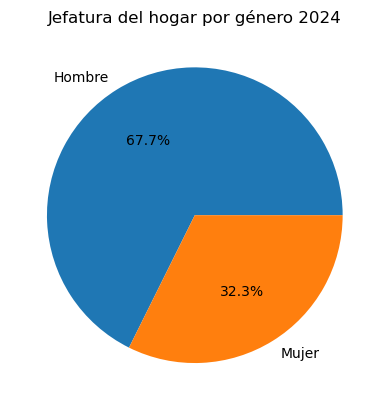

In [40]:
plt.pie([67.66,32.34], labels=['Hombre','Mujer'], autopct='%1.1f%%')
plt.title('Jefatura del hogar por género 2024')
plt.show()

Estos datos muestran un aumento en las madres siendo jefas de hogar, lo cual podría explicarse por diversos factores que no abarcaremos en este proyecto, los cuales podrían ser aumento en los divorcios, mayores padres ausentes o tal vez padres que les fue arrebatada la vida y la mujer quedó al frente del hogar

Ahora determinaremos el ingreso promedio de acuerdo al sexo del jefe del hogar

In [41]:
enigh.groupby(['año','sexo_jefe'])['ing_cor'].median()

año   sexo_jefe
2018  1           34,647
      2           30,698
2024  1           42,603
      2           38,755
Name: ing_cor, dtype: float64

Vemos que el ingreso medio de los hombres aumentó un 22.96% mientras que el salario de las mujeres aumentó un 26.24%, vamos a verlo en una gráfica

In [44]:
salario_medio=enigh.groupby(['año','sexo_jefe'])['ing_cor'].median()
print(salario_medio)

año   sexo_jefe
2018  1           34,647
      2           30,698
2024  1           42,603
      2           38,755
Name: ing_cor, dtype: float64


In [45]:
salario_medio = salario_medio.reset_index()

([<matplotlib.axis.XTick at 0x24f832a9a90>,
 [Text(0, 0, 'Hombre'), Text(1, 0, 'Mujer')])

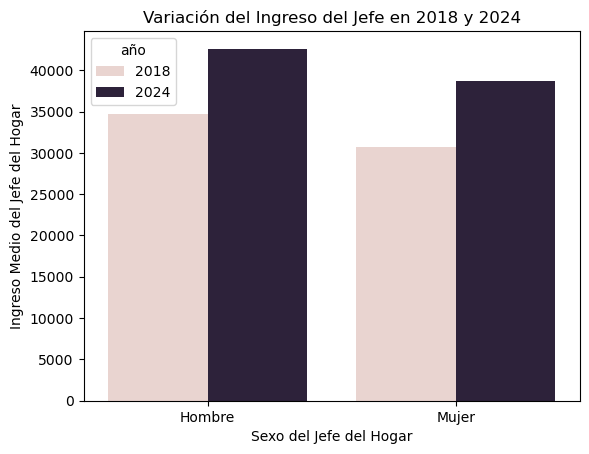

In [47]:
sns.barplot(data=salario_medio, x = 'sexo_jefe', y = 'ing_cor', hue= 'año')
plt.xlabel("Sexo del Jefe del Hogar")
plt.ylabel("Ingreso Medio del Jefe del Hogar")
plt.title("Variación del Ingreso del Jefe en 2018 y 2024")
plt.xticks([0,1],['Hombre','Mujer'])

Al revisar los datos podemos ver que las mujeres tuvieron un incremeto mayor al de los hombres, pero ¿por qué?. 
No estudiaremos a fondo el tema pero eso podría explícarse ya que en el gobierno de AMLO incrementó el salario mínimo de forma exponencial, pasando de $88/día a $248.93/día. Y un punto importante a mencionar es que las mujeres históricamente han estado más concentradas en empleos donde su sueldo es el salario mínimo o cerca, podemos dar el ejemplo del trabajo doméstico, comercio informal o servicios. Así que ese incremento salarial las beneficio más a ellas. Ahora bien, otro punto importantísimo son los apoyos del gobierno, los cuales se le brindan mayormente a mujeres, como pensión para el bienestar, apoyo a madres solteras. veámoslo rápido en datos.

In [52]:
enigh.groupby(['año','sexo_jefe'])['bene_gob'].mean()

año   sexo_jefe
2018  1             826
      2             775
2024  1           1,908
      2           1,968
Name: bene_gob, dtype: float64

In [54]:
enigh.groupby(['año','sexo_jefe'])['bene_gob'].median()

año   sexo_jefe
2018  1           0
      2           0
2024  1           0
      2           0
Name: bene_gob, dtype: float64

Acabamos de ver algo bastante importante, yo creía que las mujeres tenían más apoyos económicos, pero los datos dicen que no es verdad, que realmente es casi igual, y al que la mediana nos de 0 significa que más del 50% de los hogares no recibe ningun apoyo, por lo tanto el principal factor del mayor crecimiento en mujeres sigue siendo el salario mínimo. 

### Por eso es importante revisar lo que dicen los datos, yo en este proyecto trato de compartir ideas mías pero es completamente válido estar en un error y que los datos nos corríjan ###

Ahora vamos a calcular la distribución porcentual de hogares para cada año dependiendo del tamaño de la localidad de los encuestados

Lo primero que haremos será una pivot_table para ver como están distribuidos los encuestados con respecto al tamaño de su localidad

En el pdf que explica todo lo relacionado con la encuesta nos dice que 

1 es <2,500 habitantes (rural disperso)
2 es 2500 - 14,999 hab.
3 es 15,000 - 99,999 hab.
4 es >= 100,000 hab.

In [62]:
pd.pivot_table(enigh, values='folioviv', index=['año','tam_loc'], aggfunc= 'count')

folioviv
año  tam_loc          
2018 1           26689
     2            9462
     3            9858
     4           28638
2024 1           34307
     2           10453
     3           10829
     4           35825

Vemos que la mayor parte de los encuestados se encuentran en 1 y 4 

Ahora vamos a crear la variable para tener todos estos datos guardados

In [64]:
tam_dist = enigh.groupby(['año','tam_loc'])['folioviv'].count()
tam_dist

año   tam_loc
2018  1          26689
      2           9462
      3           9858
      4          28638
2024  1          34307
      2          10453
      3          10829
      4          35825
Name: folioviv, dtype: int64

Para lograr sacar el porcentaje tenemos que tener el total de cada uno y recordemos que tenemos diferente cantidad de encuestados en 2018 y 2024

In [65]:
tam_dist.groupby(level='año').transform('sum')

año   tam_loc
2018  1          74647
      2          74647
      3          74647
      4          74647
2024  1          91414
      2          91414
      3          91414
      4          91414
Name: folioviv, dtype: int64

Ya con los totales podemos sacar los porcentajes con una sencilla operación

In [67]:
porcentajes_tam_loc = (tam_dist/tam_dist.groupby(level='año').transform('sum'))*100
porcentajes_tam_loc

año   tam_loc
2018  1         36
      2         13
      3         13
      4         38
2024  1         38
      2         11
      3         12
      4         39
Name: folioviv, dtype: float64

Como lo vimos hace unos pasos el sector 1 representa el 36% de la población y el sector 4 el 38% en el 2018, mientras que en el 2024 el sector 1 representa el 38% de la población y el sector 4 el 39%. Esto nos dice que la mayoría de la gente vive ya sea en zonas rurales o en zonas urbanas, muy pocas viven en el 2 y 3. 
Ahora, es importante ver que el sector rural creció de 36% al 38%, es decir que hubo un incremento en zonas rurales en 2024 mientras que el aumento en zonas urbanas no creció tanto. 
Para eso pueden haber varias explicaciones como que el diseño muestral varia entre ediciones o que los programas sociales rurales durante ese periodo incentivaron que más hogares rurales participaran en la encuesta, realmente no podemos decretar ciertamente el por qué de ese aumento.

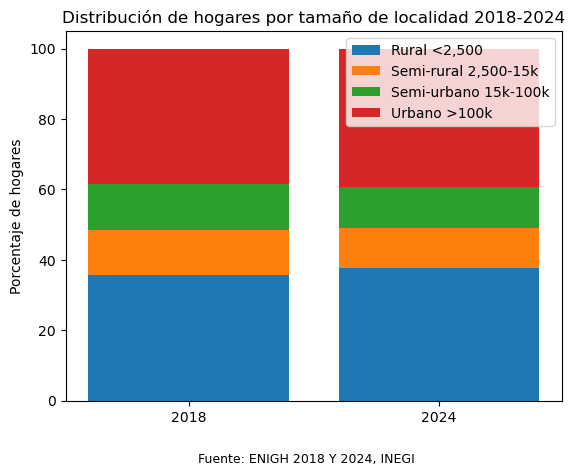

In [70]:
data = porcentajes_tam_loc.reset_index()

data_2018 = data[data['año'] == 2018]
data_2024 = data[data['año'] == 2024]

plt.bar(['2018', '2024'],
        [data_2018['folioviv'].values[0], data_2024['folioviv'].values[0]],
        label='Rural <2,500')

plt.bar(['2018', '2024'],
        [data_2018['folioviv'].values[1], data_2024['folioviv'].values[1]],
        bottom=[data_2018['folioviv'].values[0],
                data_2024['folioviv'].values[0]],
        label='Semi-rural 2,500-15k')

plt.bar(['2018', '2024'],
        [data_2018['folioviv'].values[2], data_2024['folioviv'].values[2]],
        bottom=[data_2018['folioviv'].values[0] + data_2018['folioviv'].values[1],
                data_2024['folioviv'].values[0] + data_2024['folioviv'].values[1]],
        label='Semi-urbano 15k-100k')

plt.bar(['2018', '2024'],
        [data_2018['folioviv'].values[3], data_2024['folioviv'].values[3]],
        bottom=[data_2018['folioviv'].values[0] + data_2018['folioviv'].values[1] + data_2018['folioviv'].values[2],
                data_2024['folioviv'].values[0] + data_2024['folioviv'].values[1] + data_2024['folioviv'].values[2]],
        label='Urbano >100k')

plt.ylabel('Porcentaje de hogares')
plt.title('Distribución de hogares por tamaño de localidad 2018-2024')
plt.legend(loc='upper right')
plt.figtext(0.5, -0.02, 'Fuente: ENIGH 2018 Y 2024, INEGI', ha="center", fontsize=9)
plt.show()

Ahora teniendo en cuenta todos los datos que hemos revisado, creo que sería bueno ver el nivel académico promedio de los mexicanos

In [75]:
enigh.groupby(['año','educa_jefe'])['folioviv'].count()

año   educa_jefe
2018  1              5477
      2                77
      3             12744
      4             12938
      5              2517
      6             19906
      7              2459
      8              8430
      9              2054
      10             6783
      11             1262
2024  1              5416
      2                27
      3             12897
      4             14898
      5              2676
      6             24884
      7              2802
      8             12709
      9              2907
      10            10172
      11             2026
Name: folioviv, dtype: int64

Vamos a intentar otra forma de ver los datos, y les pondré su equivalente para entender más fácil y rápido

In [80]:
nombres_educa = {
    1: 'Sin instrucción',
    2: 'Preescolar',
    3: 'Primaria incompleta',
    4: 'Primaria completa',
    5: 'Secundaria incompleta',
    6: 'Secundaria completa',
    7: 'Preparatoria incompleta',
    8: 'Preparatoria completa',
    9: 'Profesional incompleta',
    10: 'Profesional completa',
    11: 'Posgrado'}

pd.pivot_table(enigh, values='folioviv', index='educa_jefe', columns='año', aggfunc='count').rename(index=nombres_educa)

año,2018,2024
educa_jefe,,
Sin instrucción,5477,5416
Preescolar,77,27
Primaria incompleta,12744,12897
Primaria completa,12938,14898
Secundaria incompleta,2517,2676
Secundaria completa,19906,24884
Preparatoria incompleta,2459,2802
Preparatoria completa,8430,12709
Profesional incompleta,2054,2907


Ya con los datos bien acomodados, podemos observar que una gran parte de la población tiene únicamente la secundaria completa, y menos de la mitad cuentan con carrera universitaria y menos de un 2.5% tienen un posgrado, eso puede demostrar el hecho de que la media de los salarios sea tan baja en el país y aparte la cantidad que le sigue esta en primaria completa y muy de cerca la primaria incompleta.
Ahora para tener más exactitud vamos a sacar los porcentajes. Porque recordemos que las encuestas tienen cantidades diferentes.

In [81]:
educa_porc = enigh.groupby(['año','educa_jefe'])['folioviv'].count()
educa_porc

año   educa_jefe
2018  1              5477
      2                77
      3             12744
      4             12938
      5              2517
      6             19906
      7              2459
      8              8430
      9              2054
      10             6783
      11             1262
2024  1              5416
      2                27
      3             12897
      4             14898
      5              2676
      6             24884
      7              2802
      8             12709
      9              2907
      10            10172
      11             2026
Name: folioviv, dtype: int64

In [82]:
educa_porc.groupby(level='año').transform('sum')

año   educa_jefe
2018  1             74647
      2             74647
      3             74647
      4             74647
      5             74647
      6             74647
      7             74647
      8             74647
      9             74647
      10            74647
      11            74647
2024  1             91414
      2             91414
      3             91414
      4             91414
      5             91414
      6             91414
      7             91414
      8             91414
      9             91414
      10            91414
      11            91414
Name: folioviv, dtype: int64

In [83]:
porcentajes_educa_jefe = (educa_porc/educa_porc.groupby(level='año').transform('sum'))*100
porcentajes_educa_jefe

año   educa_jefe
2018  1             7
      2             0
      3            17
      4            17
      5             3
      6            27
      7             3
      8            11
      9             3
      10            9
      11            2
2024  1             6
      2             0
      3            14
      4            16
      5             3
      6            27
      7             3
      8            14
      9             3
      10           11
      11            2
Name: folioviv, dtype: float64

Vamos a verlos de la otra forma porque se aprecia mejor, la convertiremos en una pivot_table

In [85]:
pivot = pd.pivot_table(enigh, values='folioviv', index='educa_jefe',columns='año', aggfunc='count')
pivot_porc = pivot.div(pivot.sum()) * 100
pivot_porc.rename(index=nombres_educa)

año,2018,2024
educa_jefe,,
Sin instrucción,7,6
Preescolar,0,0
Primaria incompleta,17,14
Primaria completa,17,16
Secundaria incompleta,3,3
Secundaria completa,27,27
Preparatoria incompleta,3,3
Preparatoria completa,11,14
Profesional incompleta,3,3


Aquí ya podemos observar que la primaria completa bajó de un 17% a un 16% y que la primaria incompleta bajó de un 17% a un 14% , también que la preparatoria completa pasó de un 11% a un 14% y la profesional completa aumentó en 2 puntos porcentuales. Los demás parecen seguir igual, un cambio porcentual en sin instrucción, pero lo relevante es que aumentó la educación de los jefes de familia.

### Ahora vamos a revisar los deciles y continuamos con el índice de Gini ###

In [88]:
enigh2018['decil'] = pd.qcut(enigh2018['ing_cor'], q=10, labels=False)
enigh2018['decil']

0        8
1        6
2        9
3        6
4        7
        ..
74642    3
74643    0
74644    8
74645    4
74646    1
Name: decil, Length: 74647, dtype: int64

In [90]:
enigh2024['decil'] = pd.qcut(enigh2024['ing_cor'], q=10, labels=False)
enigh2024['decil']

0        9
1        8
2        4
3        8
4        7
        ..
91409    3
91410    7
91411    4
91412    0
91413    1
Name: decil, Length: 91414, dtype: int64

Aquí es importante aclarar que python al ser índice 0, tenemos que restar un número o sea que el decil 0 es el 1 y el decil 10 es el 9, pero lo arreglaremos en el siguiente código

Lo que estamos haciendo es dividir a la población en 10 partes iguales ordenados de menor a mayor ingreso. Entonces el decil 1 es el 10% más pobre y el decil 10 es el 10% más rico. Entonces el punto de este subtema es ver cuántos ingresos concentran en cada grupo y ver de que forma cambiaron en los dos periodos que tenemos.

In [92]:
deciles = pd.DataFrame({
    '2018': enigh2018.groupby('decil')['ing_cor'].median(),
    '2024': enigh2024.groupby('decil')['ing_cor'].median()
})
deciles.index = range(1, 11) 
deciles

,2018,2024
1,"9,058","12,000"
2,"15,295","19,655"
3,"20,345","25,609"
4,"25,276","31,425"
5,"30,571","37,814"
6,"36,832","45,048"
7,"44,574","53,920"
8,"55,196","65,906"
9,"72,607","84,769"
10,"118,229","130,006"


In [93]:
deciles['cambio_%'] = ((deciles['2024'] - deciles['2018']) / deciles['2018'] * 100).round(1)
deciles

,2018,2024,cambio_%
1,"9,058","12,000",32
2,"15,295","19,655",28
3,"20,345","25,609",26
4,"25,276","31,425",24
5,"30,571","37,814",24
6,"36,832","45,048",22
7,"44,574","53,920",21
8,"55,196","65,906",19
9,"72,607","84,769",17
10,"118,229","130,006",10


Algo relevante que vemos aquí es que el ingreso del decil 1 es decir el más pobre creció un 32% en comparación con el 10% que creció el decil más rico. Evidentemente esto suguiere una reducción en la desigualdad, la cuál es consistente con los aumentos que se le han hecho al salario mínimo.

Vamos a ver esto con una gráfica

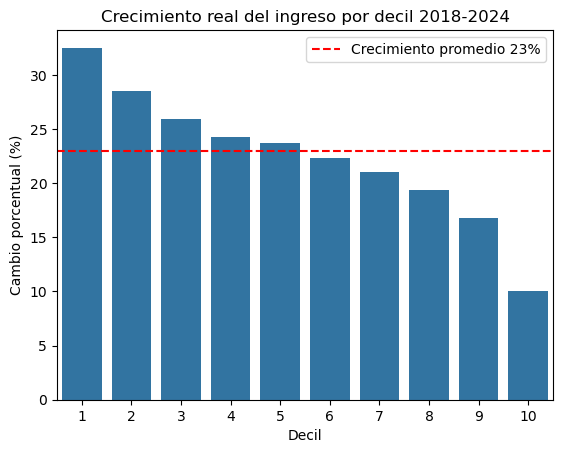

In [97]:
deciles_plot = deciles.reset_index()
deciles_plot.columns = ['decil', '2018', '2024', 'cambio_%']

sns.barplot(data=deciles_plot, x='decil', y='cambio_%')
plt.title('Crecimiento real del ingreso por decil 2018-2024')
plt.xlabel('Decil')
plt.ylabel('Cambio porcentual (%)')
plt.axhline(y=23, color='red', linestyle='--', label='Crecimiento promedio 23%')
plt.legend()
plt.show()

Ahora por último calcularemos el coeficiente de Gini para ponerle un número exacto a la reducción que descubrimos. 

In [102]:

def gini(array):
    array = np.sort(array)
    n = len(array)
    index = np.arange(1, n + 1)
    return (2 * np.sum(index * array) / (n * np.sum(array))) - (n + 1) / n

print("Gini 2018:", round(gini(enigh2018['ing_cor'].values), 3))
print("Gini 2024:", round(gini(enigh2024['ing_cor'].values), 3))

Gini 2018: 0.427
Gini 2024: 0.396


El coeficiente de Gini confirma lo que hemos visto hasta ahora en todo el documento, observamos que pasó de un 0.427 a 0.396, una reducción de 0.031 puntos en 6 años, estos números Gini lo que estan diciendo es que existe una reducción en términos de desigualdad, habría que revisar el promedio del coeficiente de Gini para ver que tanto es esa disminución de la desigualdad.

Recordemos que el Coeficiente de Gini es un número índice que mide la desigualdad, sus valores están entre el 0 y el 1, donde el 0 sería una igualdad perfecta y el 1 una desigualdad máxima.

### Ahora sería interesante ver en qué gastan los hogares mexicanos ###

In [103]:
enigh.groupby('año')[['alimentos','vesti_calz','vivienda','salud','transporte','educa_espa','comunica']].median()

,alimentos,vesti_calz,vivienda,salud,transporte,educa_espa,comunica
año,,,,,,,
2018,"8,777",606,"1,636",23,"3,484",783,600
2024,"10,310",581,"1,640",142,"4,228",619,"1,224"


En esta tabla podemos observar que en lo que gastan más las familias mexicanas es el alimento lo cuál podría parecer obvio, pero algo que llama la atención es que el transporte también es un gasto representativo, recordemos que un gran porcentaje de las personas viven en zonas rurales y probablemtente necesiten desplazarse para encontrar mejores oportunidades laborales.
Otro punto que necesita atención es el gasto en salud, le mediana de gasto en salud en 2018 fue de 23 pesos mexicanos, eso nos dice que mucha de las personas tal vez no tienen la capacidad económica para atenderse en un hospital privado y prefieren asistir tal vez a instancias públicas donde sabemos que la atención casi nunca es buena. Es un dato muy relevante que necesitaría su propio estudio. Ahora bien el incremento a 2024 fue en más de un 500% lo que refleja que pudiese haber un mayor uso de servicios particulares debido a la infeciencia del sector público o que aumentó la capacidad de gasto con respecto al aumento del salario mínimo, ó tal vez las dos juntas.

Vamos a verlo con una gráfica, pero para eso primero vamos a sacar sus porcentajes

In [104]:
gasto = enigh.groupby('año')[['alimentos','vesti_calz','vivienda','salud','transporte','educa_espa','comunica']].median()

gasto_porc = gasto.div(gasto.sum(axis=1), axis=0) * 100
gasto_porc

,alimentos,vesti_calz,vivienda,salud,transporte,educa_espa,comunica
año,,,,,,,
2018,55,4,10,0,22,5,4
2024,55,3,9,1,23,3,7


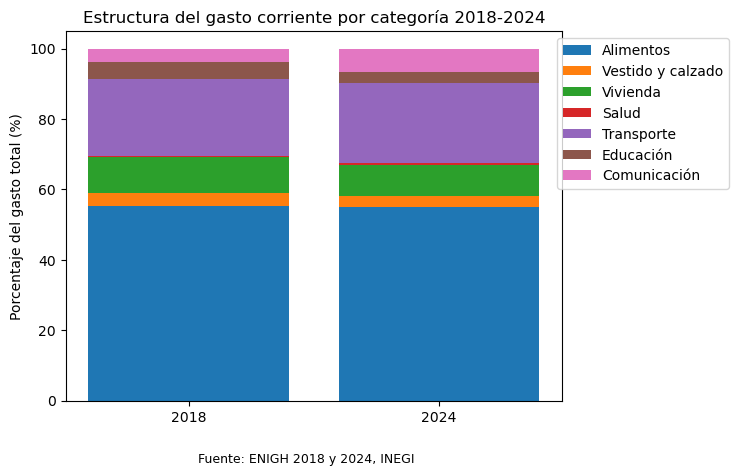

In [108]:
categorias = gasto_porc.columns
bottom_2018 = np.zeros(1)
bottom_2024 = np.zeros(1)
etiquetas = ['Alimentos', 'Vestido y calzado', 'Vivienda', 'Salud', 'Transporte', 'Educación', 'Comunicación']
colores = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2']

for cat, etiqueta, color in zip(categorias, etiquetas, colores):
    plt.bar('2018', gasto_porc.loc[2018, cat], bottom=bottom_2018, 
            label=etiqueta, color=color)
    plt.bar('2024', gasto_porc.loc[2024, cat], bottom=bottom_2024, color=color)
    bottom_2018 = bottom_2018 + gasto_porc.loc[2018, cat]
    bottom_2024 = bottom_2024 + gasto_porc.loc[2024, cat]

plt.title('Estructura del gasto corriente por categoría 2018-2024')
plt.ylabel('Porcentaje del gasto total (%)')
plt.legend(loc='upper right', bbox_to_anchor=(1.35, 1))
plt.figtext(0.5, -0.02, 'Fuente: ENIGH 2018 y 2024, INEGI', ha='center', fontsize=9)
plt.show()

Con esta gráfica podemos reforzar lo que vimos en la tabla, alimentos es en lo que más gasta la gente, por encima de un 50%, transporte representa también un gasto fuerte, también aquí notamos un decremento en educación y un aumento en comunicación.
Y bueno aquí hay un tema muy relevante que se me vino a la mente, que es la Ley de Engel.

La Ley de Engel establece que, a medida que aumentan los ingresos en el hogar, el porcentaje de ingreso que se destina a la alimentación disminuye, esto aunque el gasto total en alimentos pueda aumentar. 
Por ejemplo, los ricos gastan más dinero en comida que los pobres eso es obvio, pero la diferencia es que esa cantidad representa un porcentaje mucho menor de sus ingresos totales que en las personas que viven en pobreza.

## Conclusiones ##

El análisis realizado, revela que el ingreso corriente mediano de los hogares mexicanos creció un 23% en términos reales, una vez que ya descontamos la inflación que se acumuló en los periodos que fue de un 34.8%. El crecimiento que observamos no fue homogéneo ya que estuvo impulsado principalmente por la política que incrementó el salario mínimo, el cual pasó de $88.36 a $248.39 diarios, esta política beneficio principalmente y desproporcionadamente a los hogares con menores ingresos.

El hallazgo más relevante a mi parecer fue la reducción en la desigualdad económica. El Coeficiente de Gini disminuyó de 0.427 a un 0.396, esto se confirma en el análisis por deciles: como ya vimos el decil más pobre registró un aumento real del 32%, mientras que el decil más rico únicamente creció un 10% real.

En cuanto a los perfiles del hogar, observamos cambios estructurales que son relevantes como el procentaje de jefas del hogar que aumentó de un 27.4% a un 32.3%, también observamos que el nivel educativo de los jefes de familia aumentó, y que la distribución rural / urbana se mantuvo estable. 

Respecto al gasto, notamos que el 55% del ingreso se destina a alimentos, esto indica que, a pesar del crecimiento registrado y corroborado, el nivel de vida promedio de los hogares mexixanos sigue siendo bajo y vulnerable a choques en precios de alimentos y energía.